In [18]:
import os
import farsight as fs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import synth_reader as sr
from astropy.io import fits
from astropy.table import Table
from joblib import Parallel, delayed

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from astropy.table import join

from sklearn.decomposition import PCA

import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
from getdist import plots, MCSamples
import zeus
from zeus import ChainManager
import numpy as np
import scipy.optimize as op
from multiprocessing import Pool

from pysr import PySRRegressor

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [19]:
FADO = Table.read(fits.open('FadoGordonBest_Run.fits')[1])

class Data_get:
    def __init__(self,data,outliers,select):
        self.data = data
        self.outliers = outliers
        self.data_clean = None
        self.select = select #Debe ser una lista de Tuplas
        self.set = None
        self.remove_outliers()
        self.set_selection()


    def remove_outliers(self):
        tmp_dataFrame = self.data
        for x in self.outliers:
            tmp_dataFrame = tmp_dataFrame[tmp_dataFrame['TAB5_INDEX']!=x]
        self.data_clean = tmp_dataFrame 

    def set_selection(self):
        tmp_dataFrame = self.data_clean
        for s in range(len(self.select)):
            if self.select[s][1] == '==':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]==self.select[s][2]]
            elif self.select[s][1] == '!=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]!=self.select[s][2]]
            elif self.select[s][1] == '>=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>=self.select[s][2]]
            elif self.select[s][1] == '<=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<=self.select[s][2]]
            elif self.select[s][1] == '>':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>self.select[s][2]]
            elif self.select[s][1] == '<':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<self.select[s][2]]
        self.set = tmp_dataFrame

    def figure_merit(self):
        x = np.array(self.set['ADEV'])
        y = np.array(self.set['chi2_red'])
        punto_ref = np.array([0, 1])
        distancias = np.sqrt((x - punto_ref[0])**2 + (y - punto_ref[1])**2)
        distancia_promedio = np.mean(distancias)

        return distancia_promedio


        
class Plotter(Data_get):
    def __init__(self,data,outliers,select):
        super().__init__(data,outliers,select)
        self.remove_outliers()
        self.set_selection()

DATA = Data_get(FADO,[56],
                [('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),#]).set
                 ('SDSS_SNR','>=',10),
                 ('ADEV','>=',0),('ADEV','<=',25),
                 ('chi2_red','>=',0.5),('chi2_red','<=',1.5)]).set



DATA['lgSFR'] = np.log10(DATA['SFR'])
DATA['lgsSFR'] = np.log10(DATA['sSFR'])
for col in DATA.colnames:
    if np.issubdtype(DATA[col].dtype, np.number):
        mask = (DATA[col] == -999.0) | (DATA[col] == 999.0)
        DATA[col][mask] = np.random.normal(loc=0.1,scale=0.1)

tabla6_2014 = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Table6_art2014.csv')
def OH_to_Z(OH):
    return 10**(OH - 8.69)

tabla6_2014['Z_convOH'] = OH_to_Z(tabla6_2014['12+logO/H'])

TABLA6_astropy = Table.from_pandas(tabla6_2014)

tabla3_2014 = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Table3_art2014.csv')

TABLA3_astropy = Table.from_pandas(tabla3_2014)

merger_i = join(DATA, TABLA6_astropy, keys='TAB5_INDEX') # MERGER 1: Tabla 6 del articulo con los datos de FADO

merger_f = join(merger_i, TABLA3_astropy, keys='TAB5_INDEX') # MERGER 1: Tabla 3 del articulo con el merger anterior


# Calculos de proporciones de masas y demas.

burstAge_L = []
burstAge_M = []

Pop_5Myr  = []
Pop_10Myr = []
Pop_30Myr = []
Pop_100Myr = []




def nebular_fraction_at_lambda(wave, F_neb, F_star, lambda0=4861, window=20):
    mask = (wave > lambda0 - window) & (wave < lambda0 + window)

    neb = np.nanmedian(F_neb[mask])
    star = np.nanmedian(F_star[mask])

    return neb / (neb + star)

def nebular_fraction_integrated(wave, F_neb, F_star, lmin=3800, lmax=7000):
    mask = (wave >= lmin) & (wave <= lmax)

    neb_int = np.trapz(F_neb[mask], wave[mask])
    total_int = np.trapz((F_neb[mask] + F_star[mask]), wave[mask])

    return neb_int / total_int


fneb_4020_list = []
fneb_4861_list = []
fneb_opt_list = []



for x in range(len(merger_f)):

    obj = merger_f['TAB5_INDEX'][x]
    obj =str(obj)

    if len(obj)!=3:
        if len(obj) == 2:
            obj = '0' + obj
        else:
            obj = '00' + obj

    spec = fs.Nebulix(home = os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',
               file = f'{obj}GOR1.MILES150_1D.fits', 
               distance = merger_f[merger_f['TAB5_INDEX']>=int(obj)]['Z'][0])
    
    SSPs = spec.population_vector.copy()

    # Convertir masa corregida a unidades físicas
    SSPs['Mcor_jMo'] = (SSPs['Mcor_j'] / 100.0) * 10**spec.fado_ensemble['lg_Mp']

    # Máscara de población joven (t < 10 Myr)
    you_mask = SSPs['logage_j'] <= 7.0

    # Extraer columnas (astropy Table soporta esto directamente)
    x = SSPs['x_j'][you_mask]          # fracción de luz (%)
    m = SSPs['Mcor_jMo'][you_mask]     # masa
    logt = SSPs['logage_j'][you_mask]  # log edad

    # (Opcional) convertir % a fracción
    x = x / 100.0

    # Inicializar valores por defecto
    Io_by_L = np.nan
    Io_by_M = np.nan

    # Promedio ponderado por luz
    if np.sum(x) > 0:
        Io_by_L = np.sum(x * logt) / np.sum(x)

    # Promedio ponderado por masa
    if np.sum(m) > 0:
        Io_by_M = np.sum(m * logt) / np.sum(m)

    # Guardar resultados
    burstAge_L.append(Io_by_L)
    burstAge_M.append(Io_by_M)


    wave = spec.spectrum_bestfit['Lambda']
    F_star = spec.spectrum_bestfit['Flux_ste']
    F_total = spec.spectrum_bestfit['Flux_syn']

    F_neb = F_total - F_star
    F_neb = np.where(F_neb > 0, F_neb, 0)

    fneb_4020 = nebular_fraction_at_lambda(
        wave, F_neb, F_star, lambda0=4020, window=20
    )

    fneb_4861 = nebular_fraction_at_lambda(
        wave, F_neb, F_star, lambda0=4861, window=20
    )

    fneb_opt = nebular_fraction_integrated(
        wave, F_neb, F_star, lmin=3800, lmax=7000
    )

    fneb_4020_list.append(fneb_4020)
    fneb_4861_list.append(fneb_4861)
    fneb_opt_list.append(fneb_opt)

    x_5Myr  = np.sum(SSPs['x_j'][SSPs['logage_j'] <= np.log10(5e6)])
    x_10Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= 7.0])
    x_30Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= np.log10(3e7)])
    x_100Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= 8.0])

    Pop_5Myr.append(x_5Myr)
    Pop_10Myr.append(x_10Myr)
    Pop_30Myr.append(x_30Myr)
    Pop_100Myr.append(x_100Myr)



merger_f['burstAge_L'] = np.array(burstAge_L)
merger_f['burstAge_M'] = np.array(burstAge_M)

merger_f['fneb_4020'] = np.array(fneb_4020_list)
merger_f['fneb_4861'] = np.array(fneb_4861_list)
merger_f['fneb_opt'] = np.array(fneb_opt_list)

merger_f['Pop_5Myr'] = np.array(Pop_5Myr)
merger_f['Pop_10Myr'] = np.array(Pop_10Myr)
merger_f['Pop_30Myr'] = np.array(Pop_30Myr)
merger_f['Pop_100Myr'] = np.array(Pop_100Myr)


merger_f['log_EWHb'] = np.log10(merger_f['EW(Hb)'])


Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [20]:
cols = [
    'lgt_av_M',
    'Z_av_M',
    'lg_Mp',
    'logL(Hb)',
    'log_sigma(Hb)',
    'log_sigma([OIII])',
    'Z',
    'lg_QH',
    'log_EWHb','burstAge_L','burstAge_M','fneb_4020','fneb_opt','Pop_5Myr','Pop_10Myr','Pop_30Myr','Pop_100Myr','logR_u','12+logO/H','logSFR','lg_MppAGB','A_neb','T_e','n_e','A_v'
]

df = merger_f.to_pandas()   # o tu tabla ya mergeada

df = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

data =df

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [21]:
merger_f.columns

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','converge','time','l_0','f_0','f_u','chi2_val','chi2_dev','chi2_red','L_dst','I_l','F_l','S_l','Cb_L','Cf_l','z','z_err','BPT_flag','BPT_Class','lgNII_Ha','elgNII_Ha','lgOIII_Hb','elgNII_Hb','T_e','n_e','A_v','eA_v','A_neb','eA_neb','v_0','ev_0','v_d','ev_d','t_av_L','et_av_L','t_av_M','et_av_M','lgt_av_L','elgt_av_L','lgt_av_M','elgt_av_M','Z_av_L','eZ_av_L','Z_av_M','etZ_av_M','lg_Me','elg_Me','lg_Mp','elg_Mp','lg_MepAGB','elg_MepAGB','lg_MppAGB','elg_MppAGB','tL_l0','etL_l0','tL_l0oneGyr','etL_l0oneGyr','tL_l0fivGyr','etL_l0fivGyr','lg_QH','elg_QH','lg_QHeI','elg_QHeI','lg_QHeII','elg_QHeII','pre_FHa','epre_FHa','pre_EWHa','epre_EWHa','pre_FHb','epre_FHb','pre_EWHb','epre_EWHb','obs_FHa','eobs_FHa','obs_EWHa','eobs_EWHa','obs_FHb','eobs_FHb','obs_EWHb','eobs_EWHb','tau_HaL','etau_HaL','tau_HaLext','etau_HaLext','tau_pAGBL','etau_pAGBL','tau_pAGBLext','etau_pAGBLext','

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

### Analisis con Hb

Ranking de importancia de parámetros para explicar el scatter:
1. logR_u (23.42%)
2. 12+logO/H (10.55%)
3. n_e (10.54%)
4. A_neb (9.04%)
5. A_v (5.83%)
6. lgt_av_M (5.19%)
7. burstAge_L (4.93%)
8. Pop_10Myr (4.41%)
9. burstAge_M (3.29%)
10. fneb_4020 (3.21%)
11. T_e (2.54%)
12. Pop_30Myr (2.06%)
13. Pop_100Myr (2.01%)
14. log_EWHb (1.97%)
15. logSFR (1.88%)
16. Z (1.74%)
17. fneb_opt (1.71%)
18. lg_QH (1.53%)
19. lg_Mp (1.37%)
20. Z_av_M (1.19%)
21. lg_MppAGB (0.83%)
22. Pop_5Myr (0.77%)


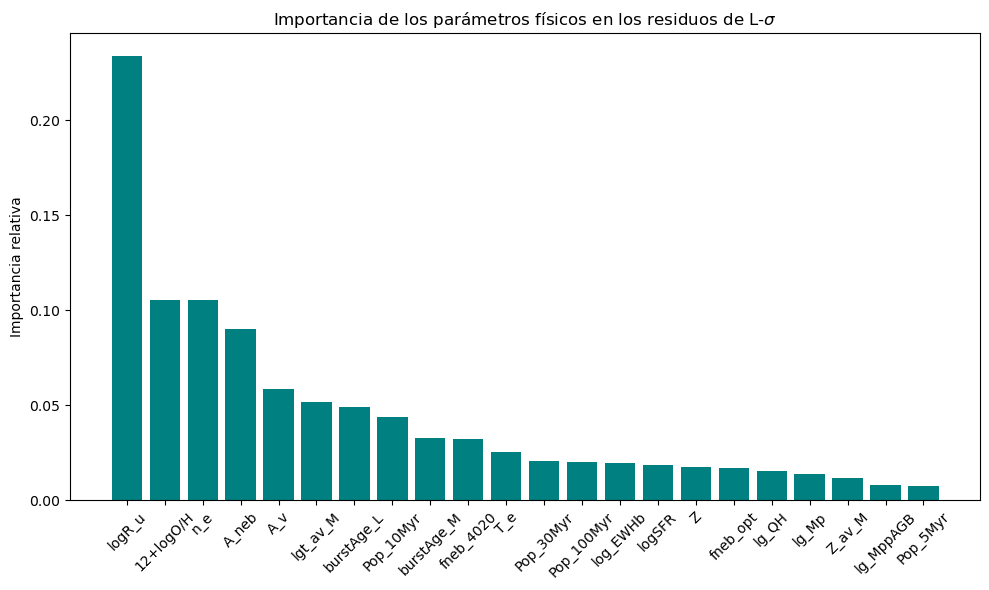

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Calculamos tus residuos observacionales reales usando tu alfa y beta óptimos:
alpha_best, beta_best = 33.2169717140405, 5.046006556006849 
log_L_obs = data['logL(Hb)']

# Tu variable objetivo (Target) es el residuo que quieres pulverizar:
data['residual'] = log_L_obs - (beta_best * data['log_sigma(Hb)'] + alpha_best)

# Definimos las matrices X (parámetros físicos) e y (residuos)
features_list = ['lgt_av_M', 'Z_av_M', 'lg_Mp','Z','lg_QH',
    'log_EWHb','burstAge_L','burstAge_M','fneb_4020','fneb_opt','Pop_5Myr','Pop_10Myr','Pop_30Myr','Pop_100Myr','logR_u','12+logO/H','logSFR','lg_MppAGB','A_neb','T_e','n_e','A_v']
X = data[features_list]
y = data['residual']

# 4. Inicializar y entrenar el Random Forest
# Usamos pocos estimadores y profundidad limitada por si tu muestra es pequeña (evitar overfitting)
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X, y)

# 5. Extraer e imprimir la importancia de los parámetros
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Ranking de importancia de parámetros para explicar el scatter:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {features_list[indices[f]]} ({importances[indices[f]]*100:.2f}%)")

# 6. Graficar los resultados
plt.figure(figsize=(10, 6))
plt.title("Importancia de los parámetros físicos en los residuos de L-$\sigma$")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), [features_list[i] for i in indices], rotation=45)
plt.ylabel("Importancia relativa")
plt.tight_layout()
plt.show()

In [23]:
data['OHratio'] = data['12+logO/H']

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [24]:
# Calculamos tus residuos observacionales reales usando tu alfa y beta óptimos:
alpha_best, beta_best = 33.2169717140405, 5.046006556006849 
log_L_obs = data['logL(Hb)']

# Tu variable objetivo (Target) es el residuo que quieres pulverizar:
data['residual'] = log_L_obs - (beta_best * data['log_sigma(Hb)'] + alpha_best)

# Definimos las matrices X (parámetros físicos) e y (residuos)
features = ['lgt_av_M','burstAge_L','burstAge_M','logR_u','OHratio','A_neb','n_e','A_v']
X = data[features].values
y = data['residual'].values

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [25]:
model = PySRRegressor(
    niterations=500,
    populations=30,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log10", "exp"], 
    
    # IMPORTANTE: 
    # Asegúrate de que los operadores en las restricciones (constraints) 
    # coincidan exactamente con los de la lista de arriba.
    constraints={
        'log10': 5, # Permite hasta 5 niveles de anidamiento dentro de un log
        'exp': 5,
        '/': (-1, 9)
    },
    
    # Si sigues teniendo problemas, quita 'nested_constraints' por un momento 
    # hasta que el modelo corra la primera vez.
    
    select_k_features=None,
    progress=True,
    loss="loss(prediction, target) = (prediction - target)^2"
)

print("Iniciando búsqueda genética de ecuaciones...")
model.fit(X, y, variable_names=features)

# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================
# Imprime el set de ecuaciones candidatas ordenadas por complejidad y precisión (Score)
print("\n--- Ecuaciones encontradas por PySR ---")
print(model.equations_)

# Puedes exportar el frente de Pareto a un archivo de texto o LaTeX
model.equations_.to_csv("pysr_lsigma_residuals.csv")

# Para usar la mejor ecuación en tu código directamente:
best_equation_prediction = model.predict(X)

/home/hollman/miniconda3/envs/cosmos/lib/python3.11/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/home/hollman/miniconda3/envs/cosmos/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


Iniciando búsqueda genética de ecuaciones...


[ Info: Final population:
[ Info: Results saved to:



--- Ecuaciones encontradas por PySR ---
    complexity      loss                                           equation  \
0            1  0.146039                                         -0.1427636   
1            3  0.141194                                n_e * -0.0011563257   
2            4  0.139304                         log10(logR_u + -2.0287342)   
3            5  0.135418                 -0.05960943 / (logR_u - 2.2765796)   
4            6  0.134797            log10(logR_u + -2.3884604) * 0.27291575   
5            8  0.134073  -0.4895448 / ((exp(logR_u) * 0.69413483) - bur...   
6            9  0.131295  (log10(logR_u + -2.3881414) * log10(n_e)) / 6....   
7           10  0.128507  (A_v * (4.7833204 - (n_e / exp(logR_u)))) / 3....   
8           11  0.119860  (((burstAge_L - (n_e / 15.672885)) * A_v) * 0....   
9           12  0.112680  ((A_v * (burstAge_L - (n_e / exp(logR_u)))) / ...   
10          14  0.108799  (OHratio + ((A_v * (burstAge_L - (n_e / exp(lo...   
11         

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

### Analisis con OIII

Ranking de importancia de parámetros para explicar el scatter:
1. logR_u (16.45%)
2. 12+logO/H (13.03%)
3. burstAge_M (8.33%)
4. Pop_10Myr (7.23%)
5. burstAge_L (6.86%)
6. Pop_5Myr (4.90%)
7. A_v (4.63%)
8. A_neb (4.49%)
9. Pop_30Myr (4.12%)
10. Z (3.69%)
11. T_e (3.63%)
12. fneb_opt (3.41%)
13. logSFR (3.01%)
14. n_e (2.99%)
15. Pop_100Myr (2.97%)
16. fneb_4020 (2.38%)
17. Z_av_M (1.57%)
18. lg_QH (1.53%)
19. lg_Mp (1.38%)
20. lgt_av_M (1.30%)
21. log_EWHb (1.16%)
22. lg_MppAGB (0.94%)


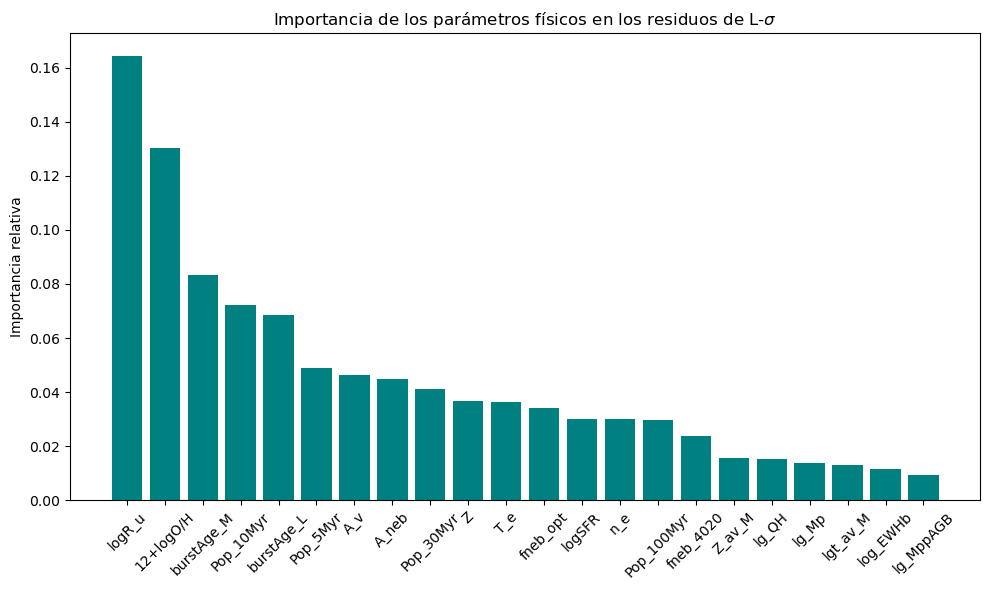

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Calculamos tus residuos observacionales reales usando tu alfa y beta óptimos:
alpha_best, beta_best = 33.2169717140405, 5.046006556006849 
log_L_obs = data['logL(Hb)']

# Tu variable objetivo (Target) es el residuo que quieres pulverizar:
data['residual'] = log_L_obs - (beta_best * data['log_sigma([OIII])'] + alpha_best)

# Definimos las matrices X (parámetros físicos) e y (residuos)
features_list = ['lgt_av_M', 'Z_av_M', 'lg_Mp','Z','lg_QH',
    'log_EWHb','burstAge_L','burstAge_M','fneb_4020','fneb_opt','Pop_5Myr','Pop_10Myr','Pop_30Myr','Pop_100Myr','logR_u','12+logO/H','logSFR','lg_MppAGB','A_neb','T_e','n_e','A_v']
X = data[features_list]
y = data['residual']

# 4. Inicializar y entrenar el Random Forest
# Usamos pocos estimadores y profundidad limitada por si tu muestra es pequeña (evitar overfitting)
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X, y)

# 5. Extraer e imprimir la importancia de los parámetros
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Ranking de importancia de parámetros para explicar el scatter:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {features_list[indices[f]]} ({importances[indices[f]]*100:.2f}%)")

# 6. Graficar los resultados
plt.figure(figsize=(10, 6))
plt.title("Importancia de los parámetros físicos en los residuos de L-$\sigma$")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), [features_list[i] for i in indices], rotation=45)
plt.ylabel("Importancia relativa")
plt.tight_layout()
plt.show()

In [27]:
data['OHratio'] = data['12+logO/H']

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [31]:
# Calculamos tus residuos observacionales reales usando tu alfa y beta óptimos:
alpha_best, beta_best = 33.2169717140405, 5.046006556006849 
log_L_obs = data['logL(Hb)']

# Tu variable objetivo (Target) es el residuo que quieres pulverizar:
data['residual'] = log_L_obs - (beta_best * data['log_sigma([OIII])'] + alpha_best)

# Definimos las matrices X (parámetros físicos) e y (residuos)
features = ['lgt_av_M','burstAge_L','burstAge_M','logR_u','OHratio','A_neb','n_e','A_v']
X = data[features].values
y = data['residual'].values

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [ ]:
model = PySRRegressor(
    niterations=500,
    populations=30,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log10", "exp"], 
    
    # IMPORTANTE: 
    # Asegúrate de que los operadores en las restricciones (constraints) 
    # coincidan exactamente con los de la lista de arriba.
    constraints={
        'log10': 5, # Permite hasta 5 niveles de anidamiento dentro de un log
        'exp': 5,
        '/': (-1, 9)
    },
    
    # Si sigues teniendo problemas, quita 'nested_constraints' por un momento 
    # hasta que el modelo corra la primera vez.
    
    select_k_features=None,
    progress=True,
    loss="loss(prediction, target) = (prediction - target)^2"
)

print("Iniciando búsqueda genética de ecuaciones...")
model.fit(X, y, variable_names=features)

# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================
# Imprime el set de ecuaciones candidatas ordenadas por complejidad y precisión (Score)
print("\n--- Ecuaciones encontradas por PySR ---")
print(model.equations_)

# Puedes exportar el frente de Pareto a un archivo de texto o LaTeX
model.equations_.to_csv("pysr_lsigma_residuals.csv")

# Para usar la mejor ecuación en tu código directamente:
best_equation_prediction = model.predict(X)

In [13]:
import numpy as np
import pandas as pd
from pysr import PySRRegressor

# ==========================================
# 1. PREPARACIÓN DE DATOS (Mock para ejemplo)
# ==========================================
# Reemplaza esto con tu DataFrame real de STARLIGHT/FADO/CIGALE
np.random.seed(42)
n_samples = 100

data = pd.DataFrame({
    'log_sigma': np.random.uniform(1.2, 2.3, n_samples),
    'M_stellar': np.random.uniform(8.0, 11.0, n_samples),     # De CIGALE/STARLIGHT
    'Age_weighted': np.random.uniform(6.0, 9.0, n_samples),   # Edad log(t)
    'Z_gas': np.random.uniform(-1.5, 0.2, n_samples),         # Metalicidad
    'AV_dust': np.random.uniform(0.1, 1.5, n_samples),        # Atenuación
    'SFR_10Myr': np.random.uniform(-2.0, 1.5, n_samples)      # De FADO
})

# Calculamos tus residuos observacionales reales usando tu alfa y beta óptimos:
alpha_best, beta_best = 4.0, 40.5 
log_L_obs = alpha_best * data['log_sigma'] + beta_best + np.random.normal(0, 0.15, n_samples)

# Tu variable objetivo (Target) es el residuo que quieres pulverizar:
data['residual'] = log_L_obs - (alpha_best * data['log_sigma'] + beta_best)

# Definimos las matrices X (parámetros físicos) e y (residuos)
features = ['M_stellar', 'Age_weighted', 'Z_gas', 'AV_dust', 'SFR_10Myr']
X = data[features].values
y = data['residual'].values

# ==========================================
# 2. CONFIGURACIÓN Y EJECUCIÓN DE PYSR
# ==========================================
# Definimos los operadores de forma explícita
# Usamos 'np.log10' para que PySR lo reconozca como el operador logarítmico
model = PySRRegressor(
    niterations=100,
    populations=20,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log10", "exp"], 
    
    # IMPORTANTE: 
    # Asegúrate de que los operadores en las restricciones (constraints) 
    # coincidan exactamente con los de la lista de arriba.
    constraints={
        'log10': 5, # Permite hasta 5 niveles de anidamiento dentro de un log
        'exp': 5,
        '/': (-1, 9)
    },
    
    # Si sigues teniendo problemas, quita 'nested_constraints' por un momento 
    # hasta que el modelo corra la primera vez.
    
    select_k_features=None,
    progress=True,
    loss="loss(prediction, target) = (prediction - target)^2"
)

print("Iniciando búsqueda genética de ecuaciones...")
model.fit(X, y, variable_names=features)

# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================
# Imprime el set de ecuaciones candidatas ordenadas por complejidad y precisión (Score)
print("\n--- Ecuaciones encontradas por PySR ---")
print(model.equations_)

# Puedes exportar el frente de Pareto a un archivo de texto o LaTeX
model.equations_.to_csv("pysr_lsigma_residuals.csv")

# Para usar la mejor ecuación en tu código directamente:
best_equation_prediction = model.predict(X)

Iniciando búsqueda genética de ecuaciones...


/home/hollman/miniconda3/envs/cosmos/lib/python3.11/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/home/hollman/miniconda3/envs/cosmos/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



--- Ecuaciones encontradas por PySR ---
    complexity      loss                                           equation  \
0            1  0.021698                                       -0.022725899   
1            3  0.020820                            log10(log10(M_stellar))   
2            4  0.020210                        -328.50662 / exp(M_stellar)   
3            5  0.019590              -0.025721412 / (M_stellar - 7.922548)   
4            7  0.018770  0.0058717206 / (SFR_10Myr * (0.19429235 - Z_gas))   
5            9  0.018544  ((0.0058717206 / SFR_10Myr) / (0.19429235 - Z_...   
6           12  0.018433  log10(log10(M_stellar)) - (5.211831 / ((M_stel...   
7           14  0.017707  log10(log10(M_stellar + Z_gas)) - (5.211831 / ...   
8           15  0.017469  (log10(log10(M_stellar)) / exp(Z_gas)) - (5.14...   
9           17  0.017337  ((0.9910437 / (log10(Age_weighted) - (Z_gas * ...   
10          19  0.016815  -0.02295477 - ((4.4335546 - (0.86477375 / (log...   
11         

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data